# KPM (Chebyshev)-based mean-field SCF for large/sparse systems

`h.get_mean_field_hamiltonian_kpm` solves the same selfconsistency problem as
`get_mean_field_hamiltonian`, but obtains the density matrix from a per-k Chebyshev-moment (Kernel
Polynomial Method) expansion instead of exact diagonalization of the Bloch Hamiltonian -- useful once
the system is too large/sparse for dense diagonalization to be the bottleneck. Below it is
cross-checked directly against exact diagonalization on a small honeycomb flake, for both an onsite
$U$ and a first-neighbor $V_1$ interaction.

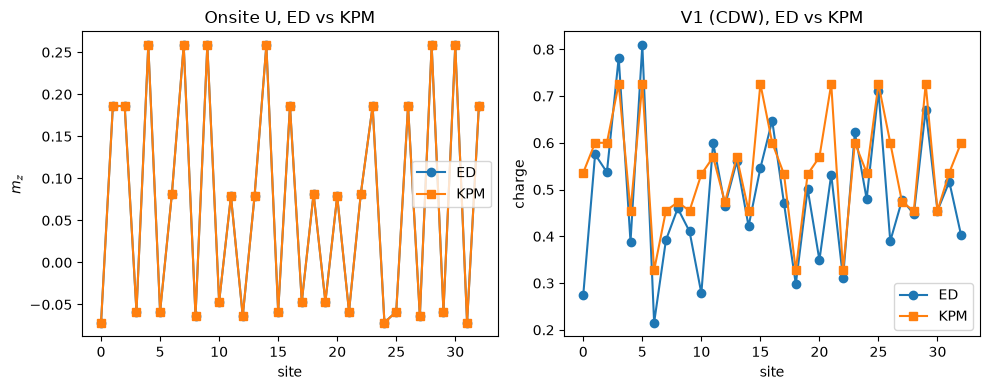

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
from pyqula import islands

def flake():
    return islands.get_geometry(name="honeycomb",n=2,nedges=3).get_hamiltonian()

common = dict(maxerror=1e-4,mix=0.5,maxite=300,verbose=0)

# onsite U, ferromagnetic guess
hed_u,_ = flake().get_mean_field_hamiltonian(filling=0.5,U=1.5,mf="ferro",**common,return_total_energy=True)
hkpm_u,_ = flake().get_mean_field_hamiltonian_kpm(filling=0.5,U=1.5,mf="ferro",npol=200,**common,return_total_energy=True)

# first-neighbor V1, seeded with a sublattice-imbalance (CDW) guess
h0 = flake() ; h0.add_sublattice_imbalance(0.2)
hed_v,_ = flake().get_mean_field_hamiltonian(filling=0.25,V1=1.0,mf=h0,**common,return_total_energy=True)
hkpm_v,_ = flake().get_mean_field_hamiltonian_kpm(filling=0.25,V1=1.0,mf=h0,npol=200,**common,return_total_energy=True)

fig,axs = plt.subplots(1,2,figsize=(10,4))
axs[0].plot(hed_u.get_magnetization()[:,2],marker="o",label="ED")
axs[0].plot(hkpm_u.get_magnetization()[:,2],marker="s",label="KPM")
axs[0].set_xlabel("site") ; axs[0].set_ylabel("$m_z$") ; axs[0].legend()
axs[0].set_title("Onsite U, ED vs KPM")
axs[1].plot(hed_v.get_vev(),marker="o",label="ED")
axs[1].plot(hkpm_v.get_vev(),marker="s",label="KPM")
axs[1].set_xlabel("site") ; axs[1].set_ylabel("charge") ; axs[1].legend()
axs[1].set_title("V1 (CDW), ED vs KPM")
plt.tight_layout()
plt.show()